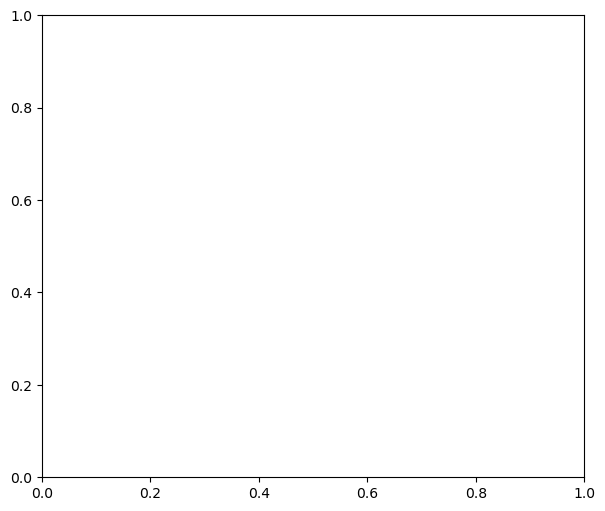

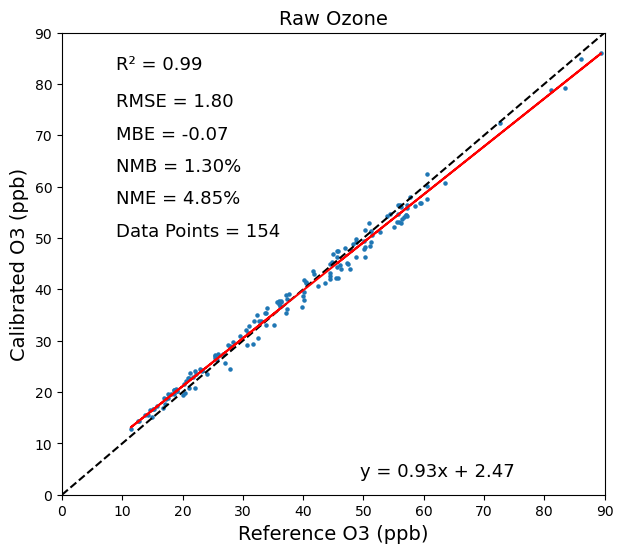

In [6]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))
from data_tools import handle_datetime
import data_tools.deployment_sets as sets
from data_tools import my_setup
from data_tools import process_data as process

aqlite_df = process.aqlite_data("../reference_files/AQLite-2025-08-15validation.csv")
carb_df = process.ref_data("../reference_files/OZONE_PICKDATA_2025-8-16-Fresno.csv")

aqlite_df = handle_datetime.utc_to_CA(aqlite_df)
carb_df = handle_datetime.utc_to_CA(carb_df)

# Resame AQLite data to hourly
aqlite_df = (
    aqlite_df.resample('1h', label='right', closed='right')
    .mean()
    .shift(freq='-30min')
)

start = pd.to_datetime("2025-08-01")
end = pd.to_datetime("2025-08-10")

all_data = aqlite_df.join(carb_df, how='inner').dropna(how = 'any')
all_data = all_data[(all_data.index >= start) & (all_data.index <= end)]

from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()
po.plot(all_data,"aqlite","All")
